In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

np.random.seed(42)
sns.set_style("whitegrid")

### Task 1: Bias Diagnosis — Case Studies

For each of the following scenarios, identify the **type of bias** present (selection bias, survivorship bias, measurement bias, response bias, or another relevant type), explain **how** it distorts the conclusions, and suggest **one concrete fix**.

**Scenario A — App Review Analysis:**
A product team analyzes their app's reviews on the App Store to understand user satisfaction. The average rating is 4.3/5, so they conclude that most users are happy. They plan to reduce investment in customer support.

**Scenario B — Startup Success Study:**
A business school studies 200 successful tech startups (all founded in the last 10 years and still operating) to identify common traits that predict startup success. They find that 80% had a pivot in their first two years and conclude that pivoting is a key success strategy.

**Scenario C — Health Survey:**
A health organization sends a voluntary online survey to 50,000 email subscribers asking about exercise habits and health outcomes. The survey receives 5,000 responses (10% response rate). Results show that respondents exercise an average of 5 hours per week and have excellent self-reported health.

**Scenario D — Salary Benchmarking:**
A recruiting platform publishes average salaries by job title based on user-submitted salary data. The platform is popular among tech workers in large cities. A company in a small town uses this data to set their salary bands.

Write your analysis in markdown cells — no code required for this task. Aim for 3–5 sentences per scenario.


**Scenario A**

**Bias Type:** This scenario exhibits response bias and selection bias. Only a subset of users—typically those with very positive or very negative experiences—choose to leave reviews, meaning the data is not representative of the full user base.

**Distortion:** The average rating of 4.3/5 likely overestimates overall user satisfaction because silent or disengaged users (who may be less satisfied) are not included. As a result, the team may draw overly optimistic conclusions and underestimate existing issues.

**Fix:** A more reliable approach would be to collect feedback from a broader and more representative sample, such as through in-app surveys or randomized prompts to all users. This would reduce bias and provide a more accurate measure of true user satisfaction.

**Scenario B — Startup Success Study:**

**Bias Type:** This scenario exhibits survivorship bias. The study only includes startups that are still operating and successful, ignoring the many startups that failed.

**Distortion:** By excluding failed startups, the analysis overrepresents traits of successful companies and may incorrectly identify pivoting as a key success factor. In reality, many failed startups may also have pivoted, so pivoting alone may not cause success.

**Fix:** The study should include both successful and failed startups to get a balanced view. Comparing traits across both groups would help identify which factors truly contribute to success rather than just appearing common among survivors.

**Scenario C — Health Survey:**

**Bias Type:** This scenario exhibits non-response bias (a form of response bias), as only 10% of the surveyed individuals responded. Those who chose to respond are likely not representative of the entire population.

**Distortion:** The results likely overestimate exercise levels and overall health, since more health-conscious or active individuals are more likely to complete the survey. As a result, the conclusions present an overly optimistic view of the population’s health.

**Fix:** To reduce bias, the organization should increase response rates through follow-ups or incentives and consider using random sampling methods. Ensuring broader participation would provide a more representative and accurate picture of the population.

**Scenario D — Salary Benchmarking:**

**Bias Type:** This scenario exhibits selection bias, as the salary data is primarily collected from tech workers in large cities and does not represent the broader population.

**Distortion:** The reported salaries are likely higher than average due to overrepresentation of high-paying urban tech jobs. As a result, a company in a small town may set unrealistic or misaligned salary bands based on this skewed data.

**Fix:** The platform should collect and report salary data from a more diverse and representative sample, including different regions and job markets. Additionally, segmenting the data by location would help companies make more accurate and relevant comparisons.

### Task 2: Create the Population

Before you can study sampling, you need a known population to sample from.

1. Generate a synthetic population of **100,000** individuals with the following columns:
   - `age`: integers drawn from a realistic distribution (e.g., a clipped normal centered at 40 with SD of 15, range 18–85).
   - `income`: correlated with age — use a linear relationship with noise (e.g., `income = 1500 * age + normal_noise`). Clip to a realistic range (e.g., 15,000–250,000).
   - `satisfaction`: a score from 1–10 that depends on income (higher income → slightly higher satisfaction, with plenty of noise).
   - `region`: categorical — randomly assign "Urban" (60%), "Suburban" (25%), "Rural" (15%).
2. Compute and store the **true population parameters**: mean age, mean income, mean satisfaction, and the proportion in each region.
3. Display the population summary and a grid of histograms (one per numerical variable).

These population parameters are your ground truth — everything in the following tasks is measured against them.

In [4]:
n = 100_000
age = np.random.normal(loc=40, scale=15, size=n)
age = np.clip(age, 18, 85)
age = np.round(age).astype(int)
income_noise = np.random.normal(0, 20000, n)
income = 1500 * age + income_noise
income = np.clip(income, 15000, 250000)
satisfaction_noise = np.random.normal(0, 2.0, n)
satisfaction = 3 + (income / 50000) + satisfaction_noise
satisfaction = np.clip(satisfaction, 1, 10)
region = np.random.choice(
    ["Urban", "Suburban", "Rural"],
    size=n,
    p=[0.60, 0.25, 0.15]
)

In [6]:
population = pd.DataFrame({
    "age": age,
    "income": income,
    "satisfaction": satisfaction,
    "region": region
})
population

,age,income,satisfaction,region
0,47,91111.891760,7.945919,Suburban
1,38,33892.904659,3.489401,Urban
2,50,86508.743804,2.071104,Urban
3,63,82115.230837,1.865028,Urban
4,36,47451.943873,3.263737,Rural
...,...,...,...,...
99995,37,30209.034749,2.739552,Urban
99996,31,57813.083231,2.781330,Suburban
99997,46,72200.399275,3.084732,Suburban
99998,37,72613.461737,2.308086,Suburban


In [7]:
mean_age = population["age"].mean()
mean_income = population["income"].mean()
mean_satisfaction = population["satisfaction"].mean()

region_props = population["region"].value_counts(normalize=True)

In [8]:
print("Mean age:", mean_age)
print("Mean income:", mean_income)
print("Mean satisfaction:", mean_satisfaction)

print("\nRegion proportions:")
print(region_props)

Mean age: 40.48098
Mean income: 61338.84856755806
Mean satisfaction: 4.275781694436894

Region proportions:
region
Urban       0.59927
Suburban    0.25075
Rural       0.14998
Name: proportion, dtype: float64


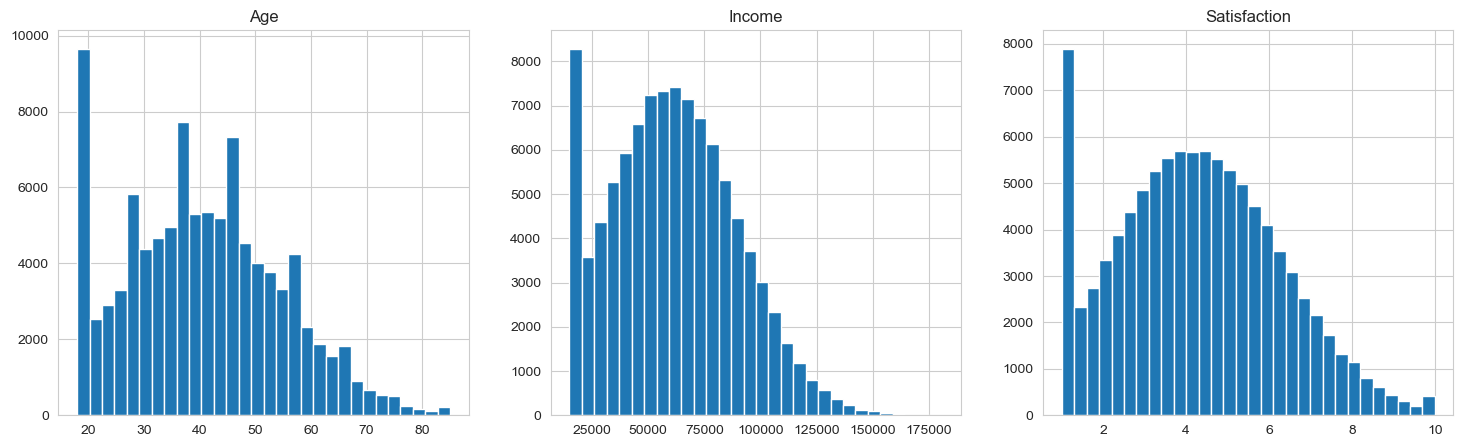

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(population["age"], bins=30)
axes[0].set_title("Age")

axes[1].hist(population["income"], bins=30)
axes[1].set_title("Income")

axes[2].hist(population["satisfaction"], bins=30)
axes[2].set_title("Satisfaction")

plt.show()

### Task 3: Biased vs. Unbiased Sampling

Draw samples from your population using three different strategies and compare how well each recovers the true population parameters.

1. **Simple random sample** (n = 200): every individual has an equal chance of being selected.
2. **Biased sample — Urban only** (n = 200): only sample from individuals in the "Urban" region.
3. **Biased sample — High-income filter** (n = 200): only sample from individuals with income above the population median.

For each sample:
- Compute mean age, mean income, and mean satisfaction.
- Display the results alongside the true population parameters in a comparison table.
- Create overlapping KDE plots (sample vs. population) for income and satisfaction.

Now, repeat each sampling strategy **1,000 times** and collect the sample means:
- Plot the **sampling distribution of the mean income** for each strategy (three histograms, side by side).
- Mark the true population mean on each histogram.

**Guiding question:** Which sampling strategies produce biased estimates? How can you tell from the sampling distributions?

In [10]:
true_mean_age = population["age"].mean()
true_mean_income = population["income"].mean()
true_mean_satisfaction = population["satisfaction"].mean()

In [11]:
random_sample = population.sample(n=200, random_state=42)

In [12]:
urban_population = population[population["region"] == "Urban"]
urban_sample = urban_population.sample(n=200, random_state=42)

In [13]:
income_median = population["income"].median()
high_income_population = population[population["income"] > income_median]
high_income_sample = high_income_population.sample(n=200, random_state=42)

In [14]:
random_stats = {
    "mean_age": random_sample["age"].mean(),
    "mean_income": random_sample["income"].mean(),
    "mean_satisfaction": random_sample["satisfaction"].mean()
}

urban_stats = {
    "mean_age": urban_sample["age"].mean(),
    "mean_income": urban_sample["income"].mean(),
    "mean_satisfaction": urban_sample["satisfaction"].mean()
}

high_income_stats = {
    "mean_age": high_income_sample["age"].mean(),
    "mean_income": high_income_sample["income"].mean(),
    "mean_satisfaction": high_income_sample["satisfaction"].mean()
}

In [15]:
comparison_table = pd.DataFrame({
    "Group": ["Population", "Simple Random", "Urban Only", "High Income Only"],
    "Mean Age": [
        true_mean_age,
        random_stats["mean_age"],
        urban_stats["mean_age"],
        high_income_stats["mean_age"]
    ],
    "Mean Income": [
        true_mean_income,
        random_stats["mean_income"],
        urban_stats["mean_income"],
        high_income_stats["mean_income"]
    ],
    "Mean Satisfaction": [
        true_mean_satisfaction,
        random_stats["mean_satisfaction"],
        urban_stats["mean_satisfaction"],
        high_income_stats["mean_satisfaction"]
    ]
})

comparison_table

,Group,Mean Age,Mean Income,Mean Satisfaction
0,Population,40.48098,61338.848568,4.275782
1,Simple Random,40.72500,63018.574380,4.265361
2,Urban Only,40.14000,61120.404860,4.442363
3,High Income Only,48.28000,83183.609475,4.730785


In [17]:
from scipy.stats import gaussian_kde

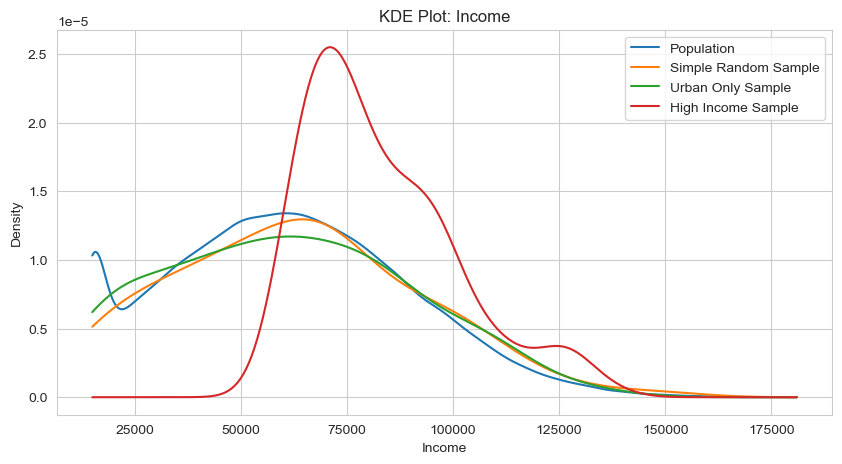

In [18]:
x_income = np.linspace(population["income"].min(), population["income"].max(), 500)

plt.figure(figsize=(10, 5))
plt.plot(x_income, gaussian_kde(population["income"])(x_income), label="Population")
plt.plot(x_income, gaussian_kde(random_sample["income"])(x_income), label="Simple Random Sample")
plt.plot(x_income, gaussian_kde(urban_sample["income"])(x_income), label="Urban Only Sample")
plt.plot(x_income, gaussian_kde(high_income_sample["income"])(x_income), label="High Income Sample")

plt.title("KDE Plot: Income")
plt.xlabel("Income")
plt.ylabel("Density")
plt.legend()
plt.show()

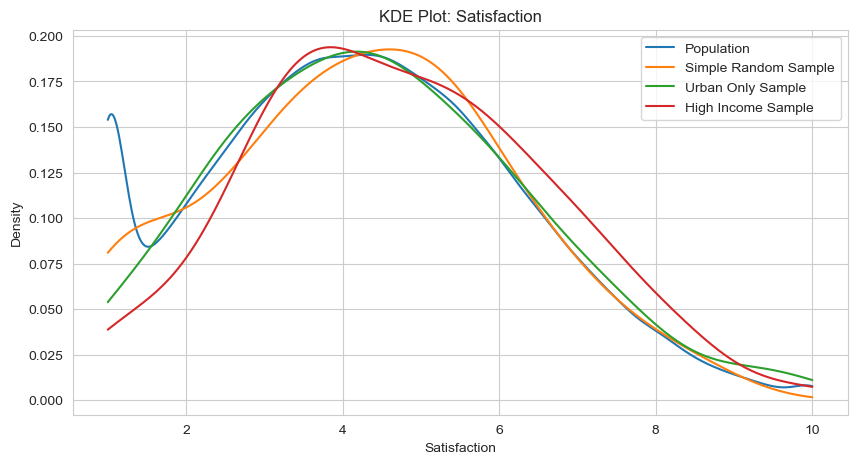

In [19]:
x_sat = np.linspace(population["satisfaction"].min(), population["satisfaction"].max(), 500)

plt.figure(figsize=(10, 5))
plt.plot(x_sat, gaussian_kde(population["satisfaction"])(x_sat), label="Population")
plt.plot(x_sat, gaussian_kde(random_sample["satisfaction"])(x_sat), label="Simple Random Sample")
plt.plot(x_sat, gaussian_kde(urban_sample["satisfaction"])(x_sat), label="Urban Only Sample")
plt.plot(x_sat, gaussian_kde(high_income_sample["satisfaction"])(x_sat), label="High Income Sample")

plt.title("KDE Plot: Satisfaction")
plt.xlabel("Satisfaction")
plt.ylabel("Density")
plt.legend()
plt.show()

In [20]:
random_income_means = []

for _ in range(1000):
    sample = population.sample(n=200, replace=False)
    random_income_means.append(sample["income"].mean())

In [21]:
urban_income_means = []

for _ in range(1000):
    sample = urban_population.sample(n=200, replace=False)
    urban_income_means.append(sample["income"].mean())

In [22]:
high_income_means = []

for _ in range(1000):
    sample = high_income_population.sample(n=200, replace=False)
    high_income_means.append(sample["income"].mean())

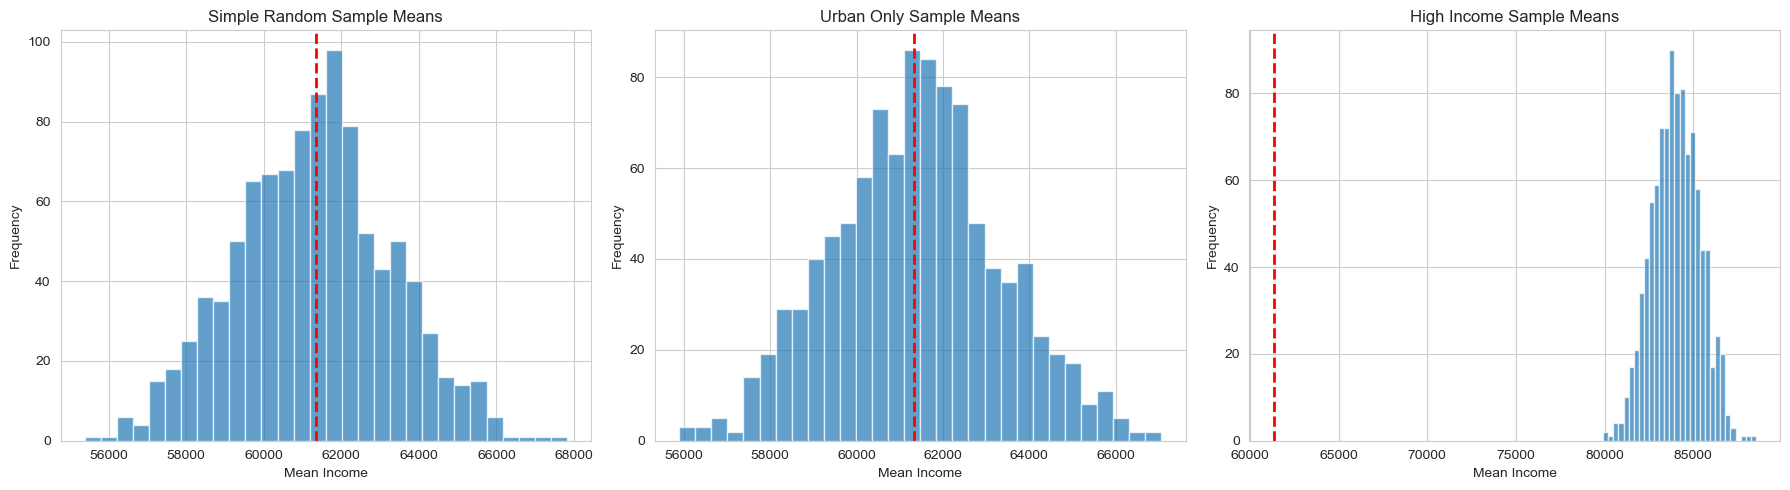

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(random_income_means, bins=30, edgecolor="white", alpha=0.7)
axes[0].axvline(true_mean_income, color="red", linestyle="--", linewidth=2)
axes[0].set_title("Simple Random Sample Means")

axes[1].hist(urban_income_means, bins=30, edgecolor="white", alpha=0.7)
axes[1].axvline(true_mean_income, color="red", linestyle="--", linewidth=2)
axes[1].set_title("Urban Only Sample Means")

axes[2].hist(high_income_means, bins=30, edgecolor="white", alpha=0.7)
axes[2].axvline(true_mean_income, color="red", linestyle="--", linewidth=2)
axes[2].set_title("High Income Sample Means")

for ax in axes:
    ax.set_xlabel("Mean Income")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

**Answer:** The **high-income-only sampling strategy clearly produces biased estimates**, as its sampling distribution is shifted far to the right of the true population mean. This indicates a systematic overestimation of income, since only higher-income individuals are included. In contrast, the **simple random sample is unbiased**, as its sampling distribution is centered around the true population mean.

The **urban-only sample is theoretically a biased strategy**, because it restricts the sample to a subset of the population. However, in this specific simulation, its sampling distribution appears very close to the true population mean. This suggests that, in this dataset, the "Urban" group has similar income characteristics to the overall population.

**Observation:** From the plots, both the simple random and urban-only sampling distributions are centered near the true mean, while the high-income sampling distribution is clearly shifted. This indicates that although urban-only sampling is conceptually biased, it happens to perform well here due to how the synthetic data was generated (region is not strongly related to income).